# Multi-Objective Plausible Inference Demo

1. **Setup** — two *unknown* convex-quadratic objectives over a triangular feasible region, a
   finite experimental set, and noisy per-objective summary statistics. We also plot the true
   Pareto front for reference.
2. **Problem configuration** — acceptability (**Pareto-optimality**), functional properties
   (**directional Lipschitz continuity**, per objective), and the confidence region
   ($\ell_\infty$ discrepancy). All three inference methods below share this configuration.
3. **Screening** — classify each candidate solution on a grid as plausibly Pareto-optimal or not.
4. **Input pixelization** — the box (outer-approximation) analogue of screening in the solution space.
5. **Output pixelization** — a confidence region for the Pareto front in the objective space.

## 1. Setup: ground truth, feasible region, and experimental set

The two unknown objectives are convex quadratics
$f_r(\mathbf{x}) = \tfrac12 \mathbf{x}^\top Q_r \mathbf{x} + c_r^\top \mathbf{x} + b_r$ ($r=1,2$),
minimized at different locations so that the Pareto front is non-trivial. The feasible region is the
triangle $\{x_1, x_2 \ge 0,\ x_1 + x_2 \le P\}$. Each experimental solution is simulated `n_rep`
times with independent Gaussian noise, giving per-objective `sample_mean` / `sample_var` /
`sample_size`.

In [1]:
import sys, os, time
import numpy as np
import scipy.stats
import pyomo.environ as pyo
from multiprocessing import Pool, cpu_count
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.plausible_inference.model_construction import (
    model_construction,
    ExecutionConfig,
    run_execution_engine,
)
from src.plausible_inference.utils.solver_config import get_plausibility_solver

In [2]:
# feasible region: triangle  x1, x2 >= 0,  x1 + x2 <= P
P = scipy.stats.gamma.ppf(0.995, 2.0, scale=2.0)
print(f"feasible-region bound P = {P:.4f}  (triangle x1 + x2 <= P)")

# two unknown convex-quadratic objectives
Q1 = np.array([[2.0, 0.4], [0.4, 1.5]]); c1 = np.array([-0.5 * P, 0.3 * P]); b1 = 0.2
Q2 = np.array([[1.2, -0.3], [-0.3, 2.0]]); c2 = np.array([0.3 * P, -0.5 * P]); b2 = 0.5

def quad_f1(z):
    z = np.asarray(z, float).reshape(2,); return 0.5 * z @ Q1 @ z + c1 @ z + b1

def quad_f2(z):
    z = np.asarray(z, float).reshape(2,); return 0.5 * z @ Q2 @ z + c2 @ z + b2

# experimental set: design points on a grid inside the triangle
rng     = np.random.default_rng(42)
num_exp = 30          # k: number of experimental solutions
n_rep   = 100         # replications per solution
noise_std1, noise_std2 = 0.3, 0.4

grid_size = 10
x1_vals = np.linspace(0, P, grid_size)
x2_vals = np.linspace(0, P, grid_size)
grid_pts = np.array([[a, b] for a in x1_vals for b in x2_vals if a + b <= P])
exp_set  = grid_pts[np.linspace(0, len(grid_pts) - 1, num_exp, dtype=int)]   # (k, 2)

# per-objective summary statistics, shape (k, 2) each
sample_mean = np.zeros((num_exp, 2))
sample_var  = np.zeros((num_exp, 2))
sample_size = np.full((num_exp, 2), n_rep, dtype=float)
for i, z in enumerate(exp_set):
    y1 = quad_f1(z) + rng.normal(0, noise_std1, n_rep)
    y2 = quad_f2(z) + rng.normal(0, noise_std2, n_rep)
    sample_mean[i] = [y1.mean(), y2.mean()]
    sample_var[i]  = [y1.var(ddof=1), y2.var(ddof=1)]

print(f"exp_set: {exp_set.shape} | sample_mean: {sample_mean.shape}")

feasible-region bound P = 14.8603  (triangle x1 + x2 <= P)
exp_set: (30, 2) | sample_mean: (30, 2)


### The two (unknown) objective functions

Filled contours of $f_1$ and $f_2$ over the feasible triangle. These are the ground-truth objectives used only to generate the noisy data; the inference method never sees them.

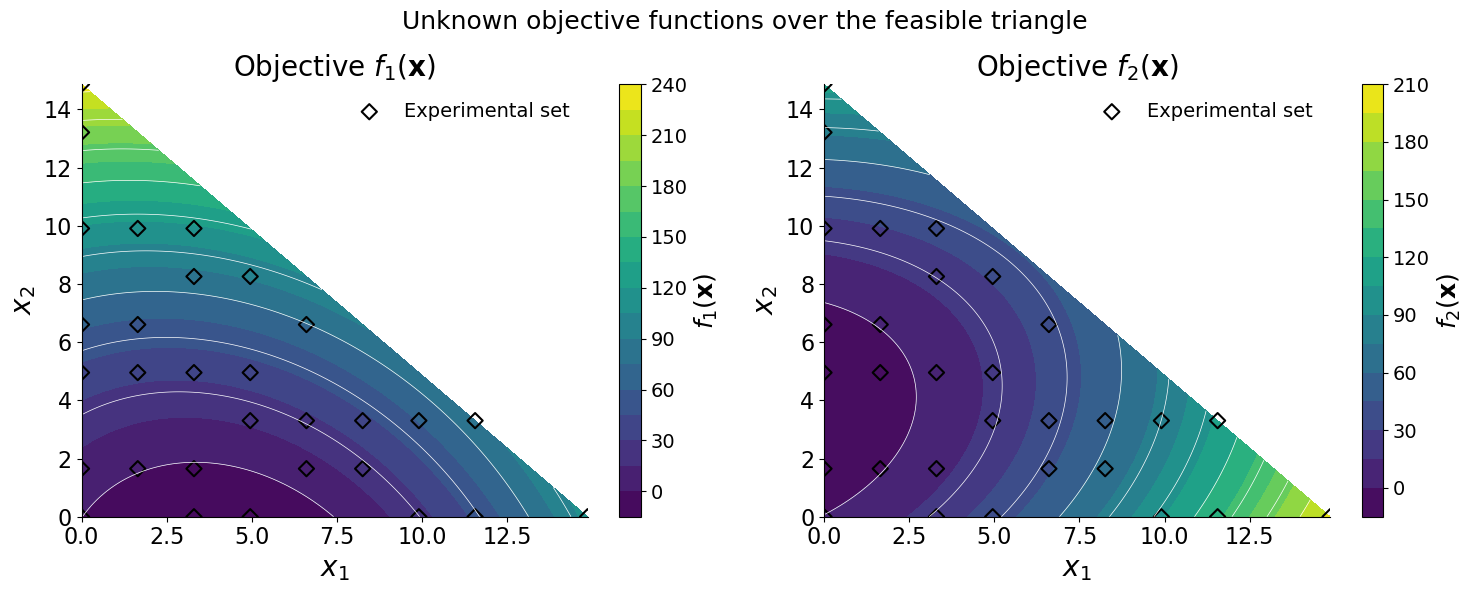

In [3]:
# contour of the two (unknown) objectives over the feasible triangle
gn = 200
gx = np.linspace(0, P, gn); gy = np.linspace(0, P, gn)
GXc, GYc = np.meshgrid(gx, gy)
inside = (GXc + GYc) <= P

def quad_grid(GX, GY, Q, c, b):
    return 0.5 * (Q[0, 0] * GX**2 + 2 * Q[0, 1] * GX * GY + Q[1, 1] * GY**2) + c[0] * GX + c[1] * GY + b

F1 = np.where(inside, quad_grid(GXc, GYc, Q1, c1, b1), np.nan)
F2 = np.where(inside, quad_grid(GXc, GYc, Q2, c2, b2), np.nan)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, Fg, name in zip(axes, [F1, F2], [r'$f_1(\mathbf{x})$', r'$f_2(\mathbf{x})$']):
    cf = ax.contourf(GXc, GYc, Fg, levels=20, cmap='viridis')
    ax.contour(GXc, GYc, Fg, levels=10, colors='white', linewidths=0.5)
    cb = fig.colorbar(cf, ax=ax)
    cb.set_label(name, fontsize=18); cb.ax.tick_params(labelsize=14)
    ax.scatter(exp_set[:, 0], exp_set[:, 1], s=60, marker='D', facecolors='none',
               edgecolors='black', linewidths=1.5, label='Experimental set')
    ax.set_xlabel(r'$x_1$', fontsize=20); ax.set_ylabel(r'$x_2$', fontsize=20)
    ax.set_title(f'Objective {name}', fontsize=20)
    ax.tick_params(labelsize=16)
    ax.legend(fontsize=14, frameon=False)
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
plt.suptitle('Unknown objective functions over the feasible triangle', fontsize=18)
plt.tight_layout(); plt.show()

### Reference: estimated Pareto front

There is **no** closed-form Pareto front available here. We *estimate* one by discretizing the
solution space on a dense grid, evaluating the **exact** (noiseless) objectives, and keeping the
non-dominated points. This grid estimate is shown only as a visual reference — the inference
methods below never use it.

Estimated Pareto-optimal grid points: 760 / 80200


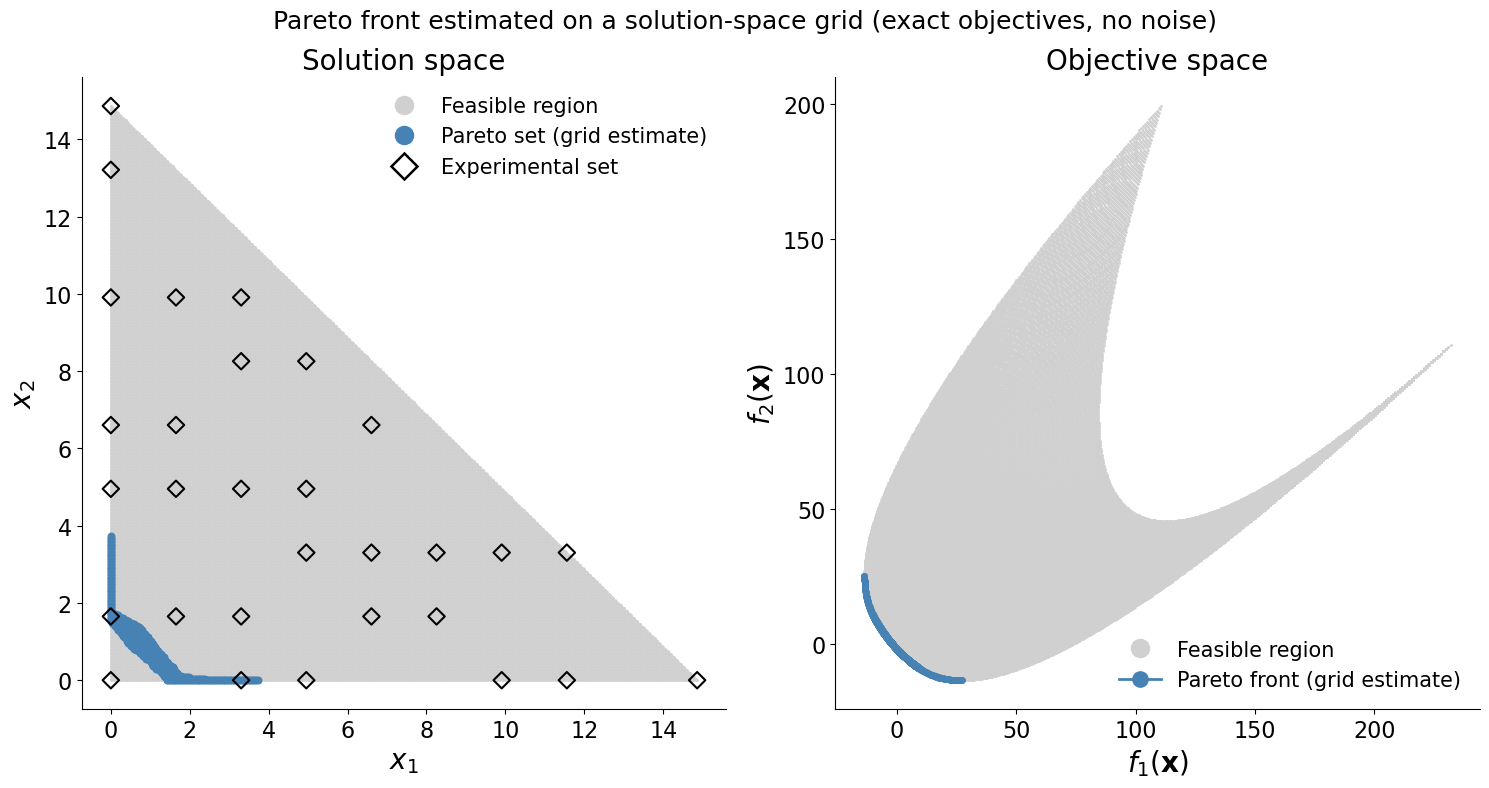

In [4]:
n_pareto_grid = 400
xa = np.linspace(0, P, n_pareto_grid); xb = np.linspace(0, P, n_pareto_grid)
GX, GY = np.meshgrid(xa, xb)
pts_grid = np.column_stack([GX.ravel(), GY.ravel()])
pts_grid = pts_grid[pts_grid[:, 0] + pts_grid[:, 1] <= P]
obj_vals = np.column_stack([[quad_f1(z) for z in pts_grid], [quad_f2(z) for z in pts_grid]])

def pareto_mask(obj):
    n = len(obj); dominated = np.zeros(n, bool)
    for i in range(n):
        if dominated[i]:
            continue
        diff = obj[i] - obj
        dom = (diff <= 0).all(axis=1) & (diff < 0).any(axis=1); dom[i] = False
        dominated |= dom
    return ~dominated

# Estimate the Pareto front by discretizing the solution space and evaluating the EXACT
# (noiseless) objectives -- there is no closed-form front; this is a reference estimate only.
mask  = pareto_mask(obj_vals)
order = np.argsort(obj_vals[mask][:, 0])
pareto_x = pts_grid[mask][order]
pareto_f = obj_vals[mask][order]
print(f"Estimated Pareto-optimal grid points: {int(mask.sum())} / {len(pts_grid)}")

# objective-space window used later by output pixelization
f1_lo, f1_hi = -15, 50
f2_lo, f2_hi = -15, 50

# explicit legend handles with large markers (the feasible-region scatter uses s=1,
# so its auto legend marker would be tiny)
handles_x = [
    Line2D([0], [0], marker='o', linestyle='none', color='#d0d0d0', markersize=13, label='Feasible region'),
    Line2D([0], [0], marker='o', linestyle='none', color='steelblue', markersize=13, label='Pareto set (grid estimate)'),
    Line2D([0], [0], marker='D', linestyle='none', markerfacecolor='none', markeredgecolor='black',
           markeredgewidth=1.8, markersize=13, label='Experimental set'),
]
handles_f = [
    Line2D([0], [0], marker='o', linestyle='none', color='#d0d0d0', markersize=13, label='Feasible region'),
    Line2D([0], [0], marker='o', linestyle='-', color='steelblue', markersize=11, lw=2.0, label='Pareto front (grid estimate)'),
]

fig, (ax_x, ax_f) = plt.subplots(1, 2, figsize=(15, 8))
ax_x.scatter(pts_grid[:, 0], pts_grid[:, 1], s=1, c='#d0d0d0')
ax_x.scatter(pareto_x[:, 0], pareto_x[:, 1], s=22, c='steelblue', zorder=3)
ax_x.scatter(exp_set[:, 0], exp_set[:, 1], s=70, marker='D', facecolors='none',
             edgecolors='black', linewidths=1.5, zorder=4)
ax_x.set_xlabel(r'$x_1$', fontsize=20); ax_x.set_ylabel(r'$x_2$', fontsize=20)
ax_x.set_title('Solution space', fontsize=20); ax_x.legend(handles=handles_x, fontsize=15, frameon=False)
ax_x.tick_params(labelsize=16)
for sp in ['top', 'right']: ax_x.spines[sp].set_visible(False)
ax_f.scatter(obj_vals[:, 0], obj_vals[:, 1], s=1, c='#d0d0d0')
ax_f.plot(pareto_f[:, 0], pareto_f[:, 1], 'o-', ms=4, color='steelblue', lw=1.5)
ax_f.set_xlabel(r'$f_1(\mathbf{x})$', fontsize=20); ax_f.set_ylabel(r'$f_2(\mathbf{x})$', fontsize=20)
ax_f.set_title('Objective space', fontsize=20); ax_f.legend(handles=handles_f, fontsize=15, frameon=False)
ax_f.tick_params(labelsize=16)
for sp in ['top', 'right']: ax_f.spines[sp].set_visible(False)
plt.suptitle('Pareto front estimated on a solution-space grid (exact objectives, no noise)', fontsize=18)
plt.tight_layout(); plt.show()

## 2. Problem configuration (shared by all three methods)

- **Acceptability** — `Pareto-optimality`: a candidate is acceptable if it is not dominated.
- **Functional properties** — `directional_Lipschitz_continuity` for each objective, with one
  Lipschitz constant per input dimension (`lip_CST_vector`).
- **Confidence region** — the $\ell_\infty$ (`norm_infinite`) discrepancy at `confidence_level`.

Candidate solutions are restricted to the triangle via the linear constraints
`x0_A_ineq @ x0 <= x0_b_ineq`.

In [5]:
# ---- acceptability + functional properties ----
num_of_objectives = 2
acceptability     = 'Pareto-optimality'

# directional Lipschitz continuity: one constant per input dimension, per objective
lip_CST_vector1 = [np.linalg.norm(Q1[:, 0]) * P + abs(c1[0]), np.linalg.norm(Q1[:, 1]) * P + abs(c1[1])]
lip_CST_vector2 = [np.linalg.norm(Q2[:, 0]) * P + abs(c2[0]), np.linalg.norm(Q2[:, 1]) * P + abs(c2[1])]
functional_properties_list       = [{'directional_Lipschitz_continuity'},
                                     {'directional_Lipschitz_continuity'}]
functional_properties_parameters = [{'lip_CST_vector': lip_CST_vector1},
                                     {'lip_CST_vector': lip_CST_vector2}]

# --- Alternative (for reference only): assert all three properties per objective ---
#     convexity + global Lipschitz continuity + directional Lipschitz continuity.
#     Such an objective needs BOTH a scalar `lip_CST` and a `lip_CST_vector`.
# lip_CST1 = float(np.linalg.norm(lip_CST_vector1))   # a global Lipschitz constant for objective 1
# lip_CST2 = float(np.linalg.norm(lip_CST_vector2))   # a global Lipschitz constant for objective 2
# functional_properties_list       = [{'convexity', 'Lipschitz_continuity', 'directional_Lipschitz_continuity'},
#                                      {'convexity', 'Lipschitz_continuity', 'directional_Lipschitz_continuity'}]
# functional_properties_parameters = [{'lip_CST': lip_CST1, 'lip_CST_vector': lip_CST_vector1},
#                                     {'lip_CST': lip_CST2, 'lip_CST_vector': lip_CST_vector2}]

# candidate x0 must lie in the triangle:  A_ineq @ x0 <= b_ineq
x0_A_ineq = np.array([[-1, 0], [0, -1], [1, 1]])
x0_b_ineq = np.array([0.0, 0.0, P])

print("acceptability:", acceptability, "| objectives:", num_of_objectives)
print("lip vectors:", [f"{v:.2f}" for v in lip_CST_vector1], [f"{v:.2f}" for v in lip_CST_vector2])

acceptability: Pareto-optimality | objectives: 2
lip vectors: ['37.74', '27.53'] ['22.84', '37.48']


In [6]:
# ---- confidence region ----
# Keep ONE discrepancy_type. norm_* and CRN are built from the statistics; 'confidence_region'
# would instead take your own upper/lower bounds (a customized hyperrectangle).
discrepancy_type = 'norm_infinite'     # alternatives: 'norm_1', 'norm_2', 'CRN'
confidence_level = 0.95

def prepare_stats(disc_type, mean, var, size):
    # Reshape per-objective statistics into the layout the model expects.
    if disc_type == 'CRN':
        k, d = mean.shape
        var_out = np.zeros((k, k, d))
        for r in range(d):
            var_out[:, :, r] = np.diag(var[:, r])
        return mean, var_out, size.min(axis=0)     # size -> (d,)
    return mean, var, size

mean_disc, var_disc, size_disc = prepare_stats(discrepancy_type, sample_mean, sample_var, sample_size)
print(f"discrepancy_type: {discrepancy_type} | "
      f"mean {mean_disc.shape}, var {var_disc.shape}, size {size_disc.shape}")

discrepancy_type: norm_infinite | mean (30, 2), var (30, 2), size (30, 2)


## 3. Screening

For each candidate solution on a grid inside the triangle, decide whether it could be
**plausibly Pareto-optimal**. The returned set is a confidence region for the grid-estimated Pareto set.

In [7]:
n_screen = 101
ws = np.linspace(0, P, n_screen)
W1, W2 = np.meshgrid(ws, ws)
candidates = np.column_stack([W1.ravel(), W2.ravel()])
feas_region = candidates[candidates[:, 0] + candidates[:, 1] <= P]
print(f"screening candidates inside triangle: {len(feas_region)}")

screening candidates inside triangle: 5151


In [8]:
solver = get_plausibility_solver('gurobi')
print("Building screening model ...")
t0 = time.time()
M_screen = model_construction(
    exp_set, num_of_objectives, 'screening', functional_properties_list,
    acceptability=acceptability, discrepancy_type=discrepancy_type,
    sample_mean=mean_disc, sample_var=var_disc, sample_size=size_disc,
    confidence_level=confidence_level,
    functional_properties_parameters=functional_properties_parameters,
    feasibility_check_solver=None,
)
print(f"  built in {time.time() - t0:.2f}s")

print(f"Screening {len(feas_region)} candidates ...")
t0 = time.time()
results_screening_df = run_execution_engine(
    ExecutionConfig(inference_type="screening", execution="parallel"),
    M_screen,
    solver,
    feas_region,
)
results_screening = results_screening_df.to_dict("records")
print(f"  done in {time.time() - t0:.2f}s")
n_feas = sum(r.get('result') == 'returned' for r in results_screening)
print(f"  plausibly Pareto-optimal: {n_feas} | screened-out: {len(results_screening) - n_feas}")

Building screening model ...
  built in 0.10s
Screening 5151 candidates ...
  done in 9.42s
  plausibly Pareto-optimal: 2829 | screened-out: 2322


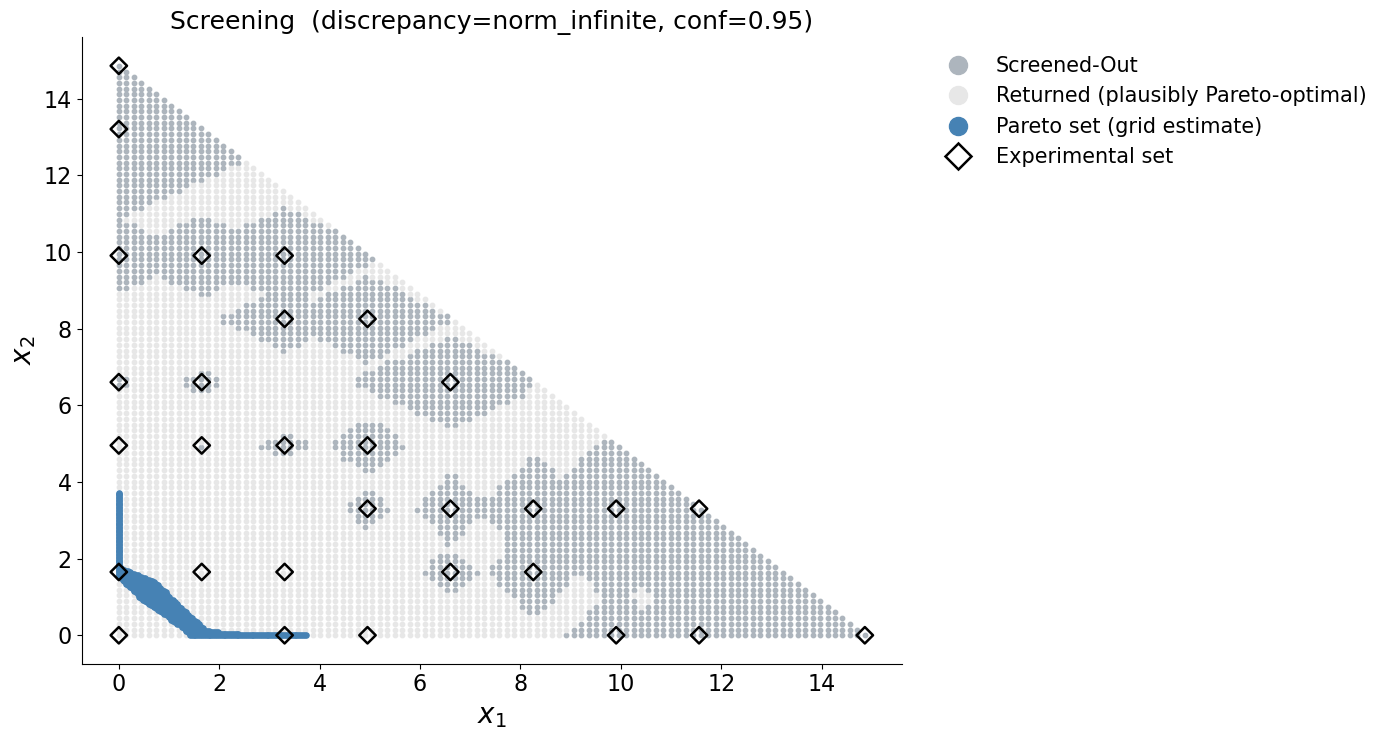

In [9]:
feasible = np.array([r.get('result') == 'returned' for r in results_screening])
plt.figure(figsize=(14, 7.5))
plt.scatter(feas_region[~feasible, 0], feas_region[~feasible, 1], s=10, c='#adb5bd')
plt.scatter(feas_region[feasible, 0],  feas_region[feasible, 1],  s=10, c='#e7e7e7')
plt.scatter(pareto_x[:, 0], pareto_x[:, 1], s=14, c='steelblue', zorder=4)
plt.scatter(exp_set[:, 0], exp_set[:, 1], s=70, marker='D', facecolors='none',
            edgecolors='black', linewidths=1.8, zorder=5)
plt.xlabel(r'$x_1$', fontsize=20); plt.ylabel(r'$x_2$', fontsize=20)
plt.title(f'Screening  (discrepancy={discrepancy_type}, conf={confidence_level})', fontsize=18)
plt.tick_params(labelsize=16)

# explicit legend handles with large markers (scatter sizes are small)
handles = [
    Line2D([0], [0], marker='o', linestyle='none', color='#adb5bd', markersize=13, label='Screened-Out'),
    Line2D([0], [0], marker='o', linestyle='none', color='#e7e7e7', markersize=13,
           label='Returned (plausibly Pareto-optimal)'),
    Line2D([0], [0], marker='o', linestyle='none', color='steelblue', markersize=13, label='Pareto set (grid estimate)'),
    Line2D([0], [0], marker='D', linestyle='none', markerfacecolor='none', markeredgecolor='black',
           markeredgewidth=1.8, markersize=13, label='Experimental set'),
]
plt.legend(handles=handles, fontsize=15, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
for sp in ['top', 'right']: plt.gca().spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Input pixelization

Partition the solution (input) space into boxes; a pixel is returned if it contains at least one
plausibly Pareto-optimal solution. This yields an **outer** approximation of the Pareto set.

In [10]:
n_grid_inp = 80
e1 = np.linspace(0, P, n_grid_inp + 1); e2 = np.linspace(0, P, n_grid_inp + 1)
pixels_inp = []
for i in range(n_grid_inp):
    for j in range(n_grid_inp):
        lb = np.array([e1[i], e2[j]]); ub = np.array([e1[i + 1], e2[j + 1]])
        if ub[0] + ub[1] <= P + 1e-9:
            pixels_inp.append((lb, ub))
print(f"input pixels inside triangle: {len(pixels_inp)}")

input pixels inside triangle: 3160


In [11]:
solver = get_plausibility_solver('scip')
print("Building input-pixelization model ...")
t0 = time.time()
M_inp = model_construction(
    exp_set, num_of_objectives, 'input_pixelization', functional_properties_list,
    acceptability=acceptability, discrepancy_type=discrepancy_type,
    sample_mean=mean_disc, sample_var=var_disc, sample_size=size_disc,
    confidence_level=confidence_level,
    functional_properties_parameters=functional_properties_parameters,
    feasibility_check_solver=None,
    x0_feasible_region_A_ineq=x0_A_ineq, x0_feasible_region_b_ineq=x0_b_ineq,
)
print(f"  built in {time.time() - t0:.2f}s")

pixel_lb = np.array([pixels_inp[i][0] for i in range(len(pixels_inp))])
pixel_ub = np.array([pixels_inp[i][1] for i in range(len(pixels_inp))])
print(f"Solving {len(pixels_inp)} pixels ...")
t0 = time.time()
results_inp_df = run_execution_engine(
    ExecutionConfig(inference_type="input_pixelization", execution="parallel"),
    M_inp,
    solver,
    (pixel_lb, pixel_ub),
)
results_inp = results_inp_df.to_dict("records")
print(f"  done in {time.time() - t0:.2f}s")
n_feas = sum(r.get('result') == 'returned' for r in results_inp)
print(f"  returned pixels: {n_feas} | screened-out: {len(results_inp) - n_feas}")

Building input-pixelization model ...
  built in 0.09s
Solving 3160 pixels ...
  done in 102.03s
  returned pixels: 1963 | screened-out: 1197


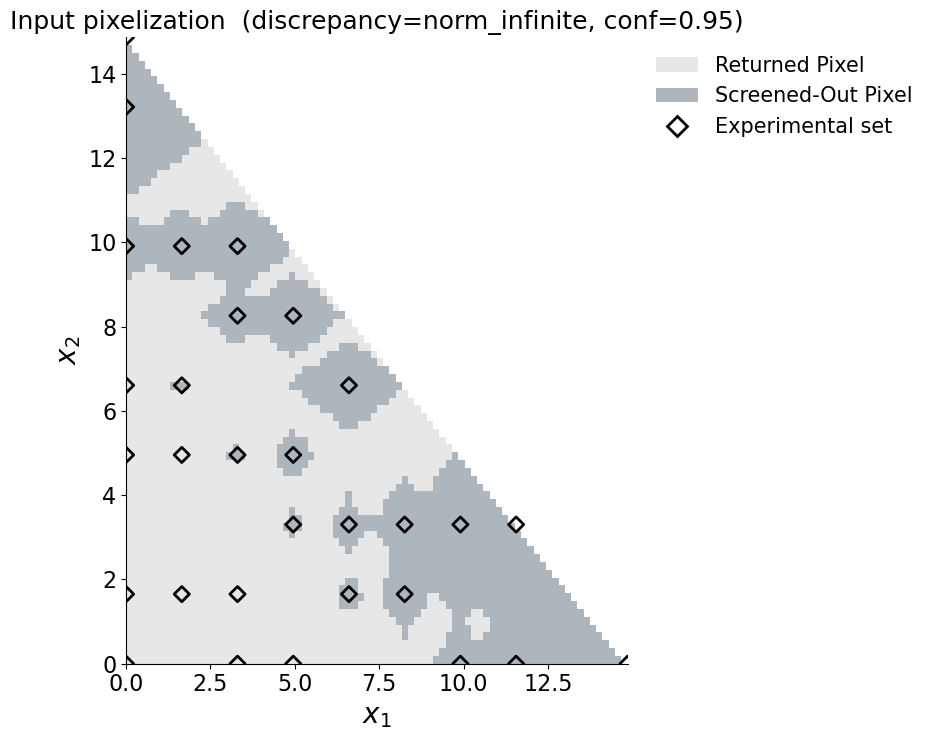

In [12]:
feas_by_idx = {r['idx']: (1 if r.get('result') == 'returned' else 0) for r in results_inp}
grid = np.full((n_grid_inp, n_grid_inp), np.nan); idx = 0
for i in range(n_grid_inp):
    for j in range(n_grid_inp):
        if e1[i + 1] + e2[j + 1] <= P + 1e-9:
            grid[i, j] = feas_by_idx.get(idx, 0); idx += 1

cmap = ListedColormap(['#adb5bd', '#e7e7e7']); cmap.set_bad('white')
plt.figure(figsize=(9, 7.5))
plt.pcolormesh(e1, e2, np.ma.masked_invalid(grid.T), shading='flat', cmap=cmap, vmin=0, vmax=1)
plt.scatter(exp_set[:, 0], exp_set[:, 1], s=60, color='none', edgecolors='black',
            linewidths=2, marker='D')
handles = [Patch(facecolor='#e7e7e7', label='Returned Pixel'),
           Patch(facecolor='#adb5bd', label='Screened-Out Pixel'),
           Line2D([0], [0], marker='D', color='w', markerfacecolor='none', markeredgecolor='black',
                  markeredgewidth=2, markersize=10, label='Experimental set')]
plt.legend(handles=handles, fontsize=15, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlabel(r'$x_1$', fontsize=20); plt.ylabel(r'$x_2$', fontsize=20)
plt.title(f'Input pixelization  (discrepancy={discrepancy_type}, conf={confidence_level})', fontsize=18)
plt.tick_params(labelsize=16)
for sp in ['top', 'right']: plt.gca().spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Output pixelization

Partition the *objective* (output) space into pixels; a pixel is returned if some plausibly
Pareto-optimal solution has an objective vector in it. The returned region is a **confidence region for the
Pareto front**. Each solve is given a time limit; pixels hitting this limit are flagged as `Timeout`.

In [13]:
n_grid_f1 = n_grid_f2 = 50
d1_edges = np.linspace(f1_lo, f1_hi, n_grid_f1 + 1)
d2_edges = np.linspace(f2_lo, f2_hi, n_grid_f2 + 1)
pixels_out = [(np.array([d1_edges[i], d2_edges[j]]), np.array([d1_edges[i + 1], d2_edges[j + 1]]))
              for i in range(n_grid_f1) for j in range(n_grid_f2)]
print(f"output pixels: {len(pixels_out)}  ({n_grid_f1} x {n_grid_f2})")

output pixels: 2500  (50 x 50)


In [14]:
solver = get_plausibility_solver('scip')
print("Building output-pixelization model ...")
t0 = time.time()
M_out = model_construction(
    exp_set, num_of_objectives, 'output_pixelization', functional_properties_list,
    acceptability=acceptability, discrepancy_type=discrepancy_type,
    sample_mean=mean_disc, sample_var=var_disc, sample_size=size_disc,
    confidence_level=confidence_level,
    functional_properties_parameters=functional_properties_parameters,
    feasibility_check_solver=None,
    x0_feasible_region_A_ineq=x0_A_ineq, x0_feasible_region_b_ineq=x0_b_ineq,
)
print(f"  built in {time.time() - t0:.2f}s")

TIMEOUT_SEC = 180
m0_lb = np.array([pixels_out[i][0] for i in range(len(pixels_out))])
m0_ub = np.array([pixels_out[i][1] for i in range(len(pixels_out))])
print(f"Solving {len(pixels_out)} output pixels (timeout {TIMEOUT_SEC}s/task) ...")
t0 = time.time()
results_out_df = run_execution_engine(
    ExecutionConfig(
        inference_type="output_pixelization",
        execution="parallel",
        time_limit_sec=TIMEOUT_SEC,
    ),
    M_out,
    solver,
    (m0_lb, m0_ub),
)
results_out = results_out_df.to_dict("records")
n_feas = sum(r.get('result') == 'returned' for r in results_out)
n_to   = sum(r.get('solve_status') == 'timeout' for r in results_out)
print(f"  done in {time.time() - t0:.2f}s | feasible {n_feas}, "
      f"infeasible {len(results_out) - n_feas - n_to}, timeout {n_to}")

Building output-pixelization model ...
  built in 0.09s
Solving 2500 output pixels (timeout 180s/task) ...
  done in 118.09s | feasible 601, infeasible 1899, timeout 0


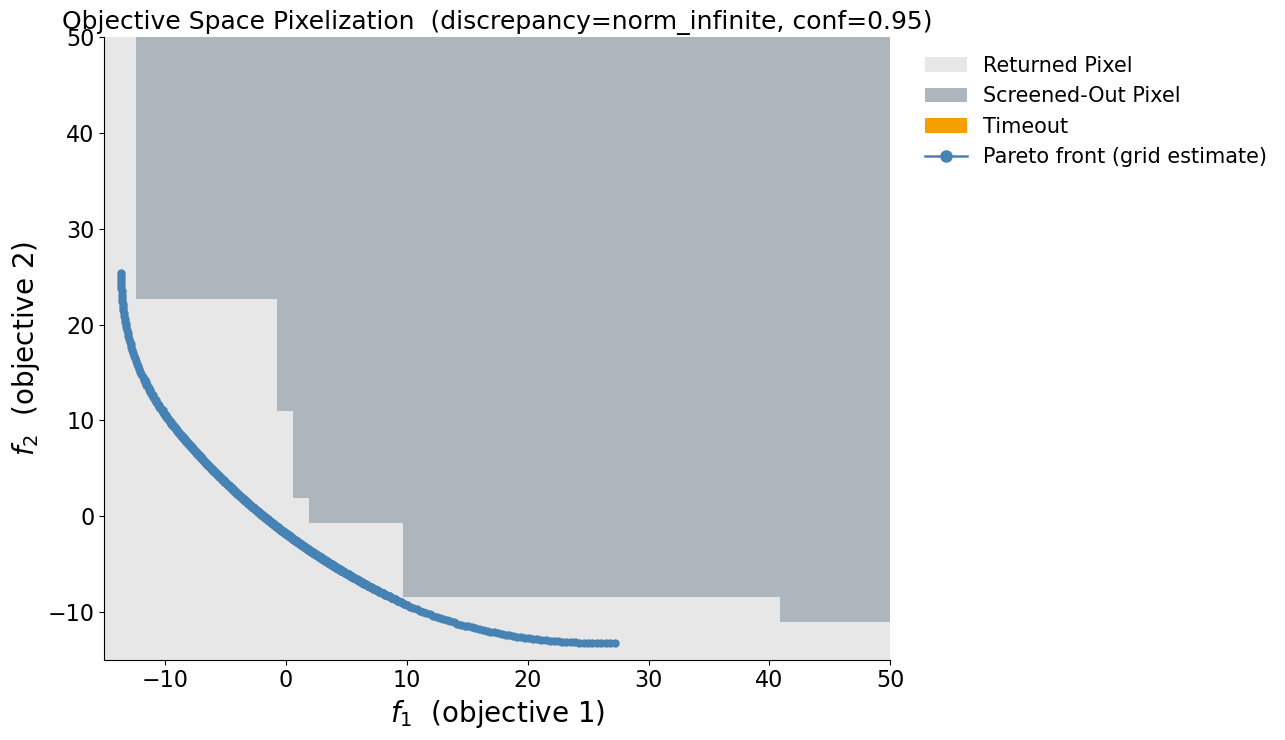

In [15]:
status = {r['idx']: (2 if r.get('solve_status') == 'timeout' else (1 if r.get('result') == 'returned' else 0))
          for r in results_out}
grid = np.array([status.get(i, 0) for i in range(len(results_out))]).reshape(n_grid_f1, n_grid_f2)

cmap = ListedColormap(['#adb5bd', '#e7e7e7', '#f59f00'])
plt.figure(figsize=(13, 7.5))
plt.pcolormesh(d1_edges, d2_edges, grid.T, shading='flat', cmap=cmap, vmin=0, vmax=2)
plt.plot(pareto_f[:, 0], pareto_f[:, 1], 'o-', ms=5, lw=1.8, color='steelblue',
         zorder=4, label='Pareto front (grid estimate)')
handles = [Patch(facecolor='#e7e7e7', label='Returned Pixel'),
           Patch(facecolor='#adb5bd', label='Screened-Out Pixel'),
           Patch(facecolor='#f59f00', label='Timeout'),
           Line2D([0], [0], marker='o', color='steelblue', ms=8, lw=1.8, label='Pareto front (grid estimate)')]
plt.legend(handles=handles, fontsize=15, frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlabel(r'$f_1$  (objective 1)', fontsize=20); plt.ylabel(r'$f_2$  (objective 2)', fontsize=20)
plt.title(f'Objective Space Pixelization  (discrepancy={discrepancy_type}, conf={confidence_level})', fontsize=18)
plt.tick_params(labelsize=16)
for sp in ['top', 'right']: plt.gca().spines[sp].set_visible(False)
plt.tight_layout(); plt.show()